<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [2]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [3]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

### Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [4]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [5]:
# Reads a CSV from the provided file path into a pandas DataFrame, using the first row as column headers.

import pandas as pd

df = pd.read_csv(file_name, header=0)
df

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150.0,47.1,1.4,8999
17962,B-MAX,2014,Manual,40700,Petrol,30.0,57.7,1.0,7499
17963,Focus,2015,Manual,7010,Diesel,20.0,67.3,1.6,9999
17964,KA,2018,Manual,5007,Petrol,145.0,57.7,1.2,8299


## Task 2 # Handling null values and duplicates 

In [6]:
# Identify columns with missing values

cols_with_na = df.columns[df.isna().any()].tolist()
print("Columns with missing values:", cols_with_na)

# Replace missing values (impute with mean) for numeric columns
for col in cols_with_na:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean())
    else:
        print(f"Column '{col}' is non-numeric; skipping mean imputation for this column.")

# Delete duplicate entries
dupes_before = df.shape[0]
df.drop_duplicates(inplace=True)
dupes_after = df.shape[0]
print(f"Removed {dupes_before - dupes_after} duplicate rows.")

# reset index after removing duplicates
df.reset_index(drop=True, inplace=True)

df.head(5)

Columns with missing values: ['tax']
Removed 154 duplicate rows.


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


## Task 3. Data Insights and Visualization 

In [7]:
# 3.1 Identify 5 attributes that have the highest correlation with the price parameter 

import numpy as np

from scipy.stats import pearsonr

def top5_correlations_with_price(df, target='price', top_n=5):
    if target not in df.columns:
        raise ValueError(f"Target column '{target}' not found in dataframe.")

    # Consider only numeric columns, exclude the target itself if present
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target in numeric_cols:
        numeric_cols.remove(target)

    results = []
    for col in numeric_cols:
        # Use rows without NaNs for this pair
        sub = df[[target, col]].dropna()
        if sub.shape[0] < 3:  # not enough data to compute a reliable correlation
            continue
        x = sub[col].values
        y = sub[target].values
        try:
            r, p = pearsonr(x, y)
            results.append({'feature': col, 'r': r, 'p': p, 'n': sub.shape[0]})
        except Exception:
            # Skip columns that cause issues (e.g., constant values)
            continue

    # Sort by absolute correlation and take top_n
    results_sorted = sorted(results, key=lambda d: abs(d['r']), reverse=True)
    return results_sorted[:top_n]

# Example usage
top_results = top5_correlations_with_price(df, target='price', top_n=5)
if top_results:
    for r in top_results:
        print(f"Feature: {r['feature']}, Pearson r = {r['r']:.4f}, p-value = {r['p']:.4g}, n={r['n']}")
else:
    print("No numeric features found to compute correlations with 'price'.")


Feature: year, Pearson r = 0.6357, p-value = 0, n=17812
Feature: mileage, Pearson r = -0.5305, p-value = 0, n=17812
Feature: engineSize, Pearson r = 0.4115, p-value = 0, n=17812
Feature: tax, Pearson r = 0.4060, p-value = 0, n=17812
Feature: mpg, Pearson r = -0.3463, p-value = 0, n=17812


In [15]:
# 3.2 Count the number of cars under each unique value of fuelType attribute.

counts = df['fuelType'].value_counts()

print("Record counts per fuelType:")
print(counts)

# for fuel, c in counts.items():
#     print(f"{fuel}: {c}")

Record counts per fuelType:
fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


Transmission category counts:
transmission
Manual       15383
Automatic     1354
Semi-Auto     1075


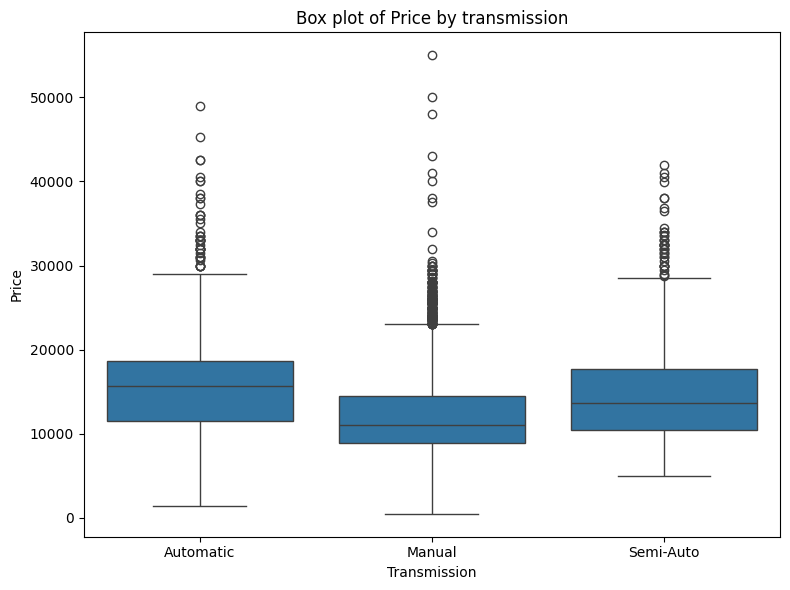


Price statistics by transmission:
                count          mean          std     min      25%      50%       75%      max
transmission                                                                                 
Automatic      1354.0  15703.494830  5940.504731  1475.0  11500.0  15677.5  18694.25  48999.0
Manual        15383.0  11783.623610  4316.333299   495.0   8890.0  10990.0  14533.00  54995.0
Semi-Auto      1075.0  14897.974884  5963.366129  4990.0  10502.5  13660.0  17709.00  42000.0


In [8]:
# 3.3. Create a Box plot to determine whether cars with automatic, manual or semi-auto type of transmission have more price outliers. Use the Seaborn library for creating the plot.

import seaborn as sns
import matplotlib.pyplot as plt

# Normalize transmission values (optional, for consistency)
df['transmission'] = df['transmission'].astype(str).str.strip()

# Transmission categories and order (sorted for consistent plotting)
trans_categories = df['transmission'].dropna().unique().tolist()
if not trans_categories:
    raise ValueError("No transmission categories found in df['transmission'].")
order = sorted(trans_categories)

# Print transmission category counts
print("Transmission category counts:")
print(df['transmission'].value_counts().to_string())

# Create box plot of Price by transmission (grouped box plots)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='transmission', y='price', order=order)
plt.title('Box plot of Price by transmission')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Optional: print descriptive statistics of Price by transmission
print("\nPrice statistics by transmission:")
stats = df.groupby('transmission')['price'].describe()
print(stats.to_string())

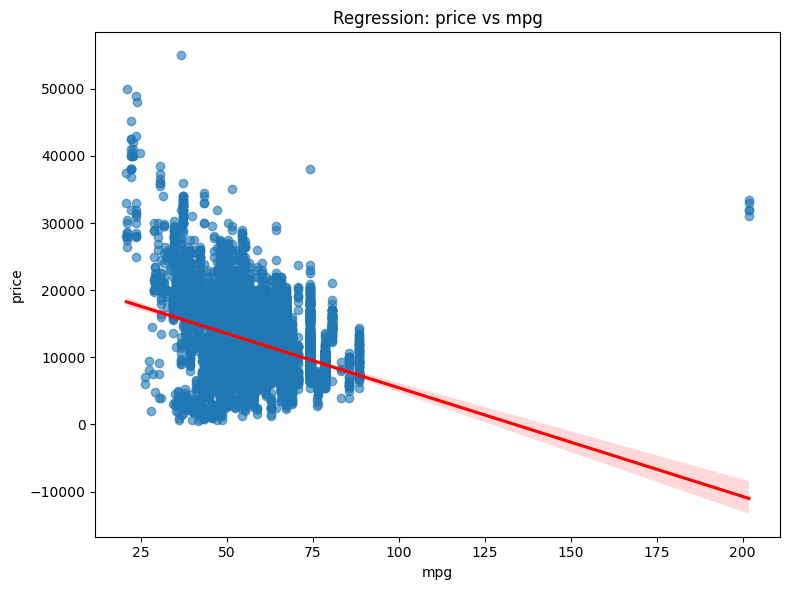

Pearson correlation: -0.346


In [16]:
# 3.4 Generate the regression plot between mpg parameter and the price to determine the correlation type between the two.

import seaborn as sns
import matplotlib.pyplot as plt

def regression_plot(df, source_attr, target_attr, figsize=(8,6), ci=95, scatter_alpha=0.6, color=None):

     
    # Validate columns                     THIS IS NOT NECESSARY, WE ARE SURE THAT THESE COLUMNS EXIST IN df 
    if source_attr not in df.columns or target_attr not in df.columns:
        raise ValueError("DataFrame df must contain both the source and target columns.")
    
    # Work on a copy and ensure numeric
    data = df[[source_attr, target_attr]].copy()
    data[source_attr] = pd.to_numeric(data[source_attr], errors='coerce')
    data[target_attr] = pd.to_numeric(data[target_attr], errors='coerce')
    data = data.dropna(subset=[source_attr, target_attr])

    if data.empty:
        raise ValueError("No valid numeric data available for regression plot after cleaning.")

    # Create regression plot
    plt.figure(figsize=figsize)
    sns.regplot(
                    x=source_attr,
                    y=target_attr,
                    data=data,
                    scatter_kws={'alpha': scatter_alpha},
                    line_kws={'color': 'red'},
                    ci=ci,
                    color=color
               )
    plt.title(f'Regression: {target_attr} vs {source_attr}')
    plt.xlabel(source_attr)
    plt.ylabel(target_attr)
    plt.tight_layout()
    plt.show()

    # Optional: print Pearson correlation
    corr = data[[source_attr, target_attr]].corr().iloc[0, 1]
    print(f"Pearson correlation: {corr:.3f}")

regression_plot(df, source_attr='mpg', target_attr='price')


## TAsk 4. Model Devlopment and Evaluatuion 

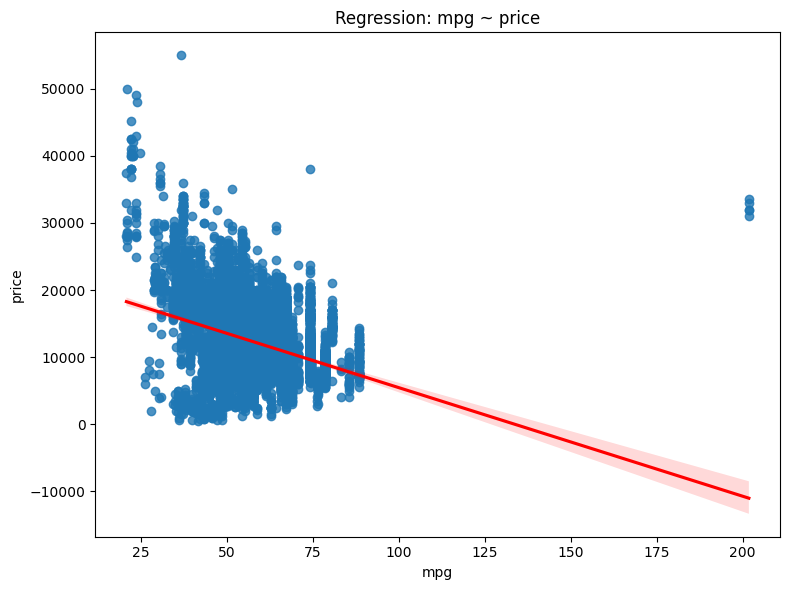

R^2: 0.1199
MSE: 19741690.8094


In [9]:
# 4.1 Fit a linear regression model to predict price using the feature mpg. Then calculate the R^2 and MSE values for the model.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def linear_regression_analysis(df, mpg, price):
    """
         Performs linear regression: mpg ~ price.
            - Fits a LinearRegression model
            - Plots regression plot
            - Returns: model, R^2, MSE
    """
    # Ensure inputs are present and numeric
    X = df[[mpg]].values  # shape (n_samples, 1)
    y = df[price].values  # shape (n_samples,)

    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Predictions and metrics
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)

    # Regression plot
    plt.figure(figsize=(8, 6))
    sns.regplot(x=mpg, y=price, data=df, line_kws={"color": "red"})
    plt.title(f"Regression: {mpg} ~ {price}")
    plt.xlabel(mpg)
    plt.ylabel(price)
    plt.tight_layout()
    plt.show()

    return model, r2, mse

model, r2, mse = linear_regression_analysis(df, "mpg", "price")
print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")

In [10]:
# 4.2 Fit a linear regression model to predict the price using the following set of features. year, mileage, tax, mpg and engineSize. Calculate the R^2 and MSE values for this model.

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def fit_target_to_five_sources(df, target_attr, source_attrs):

    """
        Fit a linear model: target_attr ~ source_attr1 + source_attr2 + source_attr3 + source_attr4 + source_attr5
    
        Parameters:
            df (pd.DataFrame): DataFrame containing the data
            target_attr (str): Name of the target column
            source_attrs (list of str): Exactly 5 source attribute column names
    
        Returns:
            model (LinearRegression): Fitted linear model
            r2 (float): R^2 score on the training data
            mse (float): Mean Squared Error on the training data
    """
    # Validate inputs   
    if not isinstance(source_attrs, (list, tuple)) or len(source_attrs) != 5:
        raise ValueError("source_attrs must be a list or tuple of exactly 5 attribute names.")
    
    missing = [c for c in [target_attr] + list(source_attrs) if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in df: {missing}")

    # Prepare data
    X = df[list(source_attrs)].values # shape (n_samples, 5)
    y = df[target_attr].values.ravel() # shape (n_samples,) - .ravel() ensures 1D array
    
    # Fit model
    model = LinearRegression()
    model.fit(X, y)

    # Predictions and metrics
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    
    return model, r2, mse

target = 'price'
sources = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

model, r2, mse = fit_target_to_five_sources(df, target, sources)

print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(sources, model.coef_)))

R^2: 0.7265
MSE: 6134065.2244
Intercept: -2441083.776813845
Coefficients: {'year': 1215.8062570897896, 'mileage': -0.05824401840783253, 'tax': 0.7848837206800295, 'mpg': -81.17034016134133, 'engineSize': 5340.315461735708}


In [19]:
#4.3 For the same set of features as in the question above, create a pipeline model object that uses standard scalar, second degree polynomial features and a linear regression model. 
#    Calculate the R^2 value and the MSE value for this model.

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def poly_pipeline_regression(df, source_attrs, target_attr, degree=2):
    """
        - df: pandas DataFrame (assumed cleaned: no NaNs, duplicates removed)
        - source_attrs: list of 5 column names to use as features
        - target_attr: column name to predict
        - degree: degree of polynomial features (default 2)
        
        Returns:
            dict with keys: 'model' (the fitted Pipeline), 'r2', 'mse', 'y_pred'
    """
    if len(source_attrs) != 5:
        raise ValueError("Exactly 5 source attributes are required.")

    # Prepare data
    X = df[source_attrs].values
    y = df[target_attr].values

    # Create pipeline: StandardScaler -> PolynomialFeatures(degree=2) -> LinearRegression
    pipe = Pipeline([
                       ('scaler', StandardScaler()),
                       ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                       ('model', LinearRegression())
   		           ])

    # Fit the model
    pipe.fit(X, y)

    # Predict on training data
    y_pred = pipe.predict(X)

    # Metrics
    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)

    return {'model': pipe, 'r2': r2, 'mse': mse, 'y_pred': y_pred}

five_sources = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_col = 'price'
result = poly_pipeline_regression(df, five_sources, target_col, degree=2)
print("R^2:", result['r2'], "MSE:", result['mse'])

#  Extract the parameter set and tyeh corresponding source attribute combination 
model_step = result['model'].named_steps['model']
poly_step = result['model'].named_steps['poly']

print("\n--- Model Parameters ---")
print("Intercept ( $\\beta_0$ ):", model_step.intercept_)
print("Coefficients ( $\\beta_1, \\beta_2, \\dots$ ):", model_step.coef_)

# Print the feature names that correspond to each coefficient
feature_names = poly_step.get_feature_names_out(five_sources)
print("\nFeature Coefficients Mapping:")
for name, coef in zip(feature_names, model_step.coef_):
    print(f"{name}: {coef:.4f}")


R^2: 0.7666619695239302 MSE: 5234038.065462741

--- Model Parameters ---
Intercept ( $\beta_0$ ): 11837.892631738385
Coefficients ( $\beta_1, \beta_2, \dots$ ): [ 3.04478688e+03 -1.22578703e+03 -9.61167173e+01 -8.71823196e+02
  2.29882378e+03 -5.71455221e+01 -7.47350142e+02  3.10892500e+02
  3.51079905e+02  3.12581411e+02 -1.73181021e+02  5.34600508e+01
  3.14128318e+02  7.67312535e+01 -1.81546157e+01  3.31418911e-01
  7.75243692e+01  6.45184632e+01  5.27998222e+01  4.18420732e+00]

Feature Coefficients Mapping:
year: 3044.7869
mileage: -1225.7870
tax: -96.1167
mpg: -871.8232
engineSize: 2298.8238
year^2: -57.1455
year mileage: -747.3501
year tax: 310.8925
year mpg: 351.0799
year engineSize: 312.5814
mileage^2: -173.1810
mileage tax: 53.4601
mileage mpg: 314.1283
mileage engineSize: 76.7313
tax^2: -18.1546
tax mpg: 0.3314
tax engineSize: 77.5244
mpg^2: 64.5185
mpg engineSize: 52.7998
engineSize^2: 4.1842


In [29]:
# For the same set of 5 features, split the data into training and testing data parts. Assume testing part to be 20%. 
# Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and 
# calculate the R^2 using the test data.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

def ridge_pipeline_run(df, feature_names=None, target_name=None, test_size=0.2, random_state=42, alpha=0.1):
    """
        Build and run a ridge regression pipeline on df.
    
        - feature_names: list of 5 column names to use as features (X). If None, the function auto-selects 5 numeric feature columns
          and 1 numeric target column from df.
        - target_name: name of the target column. Required if feature_names is provided.
        Returns a dict with:
          - X_cols, y_col, alpha, intercept, coefficients, r2
    """
    if feature_names is not None:
        X_cols = list(feature_names)
        if len(X_cols) != 5:
            raise ValueError("feature_names must be a list of 5 column names.")
        for col in X_cols:
            if col not in df.columns:
                raise ValueError(f"Feature column '{col}' not found in dataframe.")
        if target_name is None:
            raise ValueError("target_name must be provided when feature_names are specified.")
        y_col = target_name
        if y_col not in df.columns:
            raise ValueError(f"Target column '{y_col}' not found in dataframe.")
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) < 6:
            raise ValueError("DataFrame must contain at least 6 numeric columns (5 features + 1 target).")
        if 'target' in numeric_cols:
            y_col = 'target'
            X_cols = [c for c in numeric_cols if c != y_col][:5]
        elif 'y' in numeric_cols:
            y_col = 'y'
            X_cols = [c for c in numeric_cols if c != y_col][:5]
        else:
            X_cols = numeric_cols[:5]
            y_col = numeric_cols[5]
        X_cols = list(X_cols)
        if len(X_cols) < 5:
            raise ValueError("Could not determine 5 feature columns from numeric columns.")

    # Prepare data
    X = df[X_cols]
    y = df[y_col]

    # Validate numeric dtypes
    for col in X_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise ValueError(f"Feature column '{col}' is not numeric.")
    if not pd.api.types.is_numeric_dtype(df[y_col]):
        raise ValueError(f"Target column '{y_col}' is not numeric.")

    # 2.1 Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    # 2.2 Create ridge regression object (2.4 initial alpha)
    ridge = Ridge(alpha=alpha)

    # 2.3 Fit to training set
    pipe = Pipeline([('ridge', ridge)])
    pipe.fit(X_train, y_train)

    # 2.5 Regression R^2 on test set
    r2 = pipe.score(X_test, y_test)

    # 2.6 Print / return model parameters and R^2
    coefs = pipe.named_steps['ridge'].coef_
    intercept = pipe.named_steps['ridge'].intercept_

    results = {
                'X_cols': X_cols,
                'y_col': y_col,
                'alpha': pipe.named_steps['ridge'].alpha,
                'intercept': intercept,
                'coefficients': dict(zip(X_cols, coefs)),
                'r2': r2
            }
    return results

feature_list = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_name = 'price'
result = ridge_pipeline_run(df, feature_names=feature_list, target_name=target_name, test_size=0.2, random_state=42, alpha=0.1)
print(result)


{'X_cols': ['year', 'mileage', 'tax', 'mpg', 'engineSize'], 'y_col': 'price', 'alpha': 0.1, 'intercept': -2596103.631841296, 'coefficients': {'year': 1292.6295923061334, 'mileage': -0.05201945096138459, 'tax': 0.6000731235329944, 'mpg': -82.45513962909111, 'engineSize': 5371.449936664119}, 'r2': 0.6917134446113138}


In [31]:
# For the same set of features, split the data into training and testing data parts. Assume testing part to be 20%. Create and fit a Ridge regression object using the training data, 
# set the regularization parameter to 0.1, and calculate the R^2 using the test data.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def ridge_poly_pipeline_run(df, feature_names=None, target_name=None, test_size=0.2, random_state=42, alpha=0.1, degree=2):
    """
        Build and run a ridge regression pipeline with a second-order polynomial transform.
    
        - df: pandas DataFrame containing the data
        - feature_names: list of 5 column names to use as features (X). If None, auto-detect 5 numeric feature columns
                         and 1 numeric target column (as in prior examples).
        - target_name: name of the target column when feature_names is provided. Required if feature_names is given.
        - test_size: fraction of data to reserve for testing (default 0.2)
        - random_state: seed for reproducibility
        - alpha: initial regularization parameter for Ridge (default 0.1)
        - degree: degree of polynomial features (default 2 for second-order)
        
        Returns a dict with:
          - X_cols, y_col, degree, alpha
          - intercept, coefficients (as a dict mapping feature name to coef)
          - r2_train, r2_test
    """
    # 1) Determine feature columns and target column
    if feature_names is not None:
        X_cols = list(feature_names)
        if len(X_cols) != 5:
            raise ValueError("feature_names must be a list of exactly 5 column names.")
        if target_name is None:
            raise ValueError("target_name must be provided when feature_names are specified.")
        y_col = target_name
        if y_col not in df.columns:
            raise ValueError(f"Target column '{y_col}' not found in dataframe.")
        for c in X_cols:
            if c not in df.columns:
                raise ValueError(f"Feature column '{c}' not found in dataframe.")
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) < 6:
            raise ValueError("DataFrame must contain at least 6 numeric columns (5 features + 1 target).")
        if 'target' in numeric_cols:
            y_col = 'target'
            X_cols = [c for c in numeric_cols if c != y_col][:5]
        elif 'y' in numeric_cols:
            y_col = 'y'
            X_cols = [c for c in numeric_cols if c != y_col][:5]
        else:
            X_cols = numeric_cols[:5]
            y_col = numeric_cols[5]
        X_cols = list(X_cols)
        if len(X_cols) != 5:
            raise ValueError("Could not determine 5 feature columns from numeric columns.")
    
    # 2) Prepare data
    X = df[X_cols]
    y = df[y_col]

    # Validate numeric dtype
    for col in X_cols:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise ValueError(f"Feature column '{col}' is not numeric.")
    if not pd.api.types.is_numeric_dtype(df[y_col]):
        raise ValueError(f"Target column '{y_col}' is not numeric.")

    # 3) Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 4) Build pipeline: PolynomialFeatures -> Ridge
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    ridge = Ridge(alpha=alpha)
    pipe = Pipeline([('poly', poly), ('ridge', ridge)])

    # 5) Fit to training data
    pipe.fit(X_train, y_train)

    # 6) Calculate R^2 for train and test
    r2_train = pipe.score(X_train, y_train)
    r2_test = pipe.score(X_test, y_test)

    # 7) Print model parameters and feature combinations
    coef = pipe.named_steps['ridge'].coef_
    intercept = pipe.named_steps['ridge'].intercept_
    poly_feature_names = pipe.named_steps['poly'].get_feature_names_out(input_features=X_cols)

    print("Ridge with Polynomial Features (degree={}) results:".format(degree))
    print(f"Feature columns (X): {X_cols}")
    print(f"Target column (y): {y_col}")
    print(f"Intercept: {intercept:.6f}")
    print("Coefficients for polynomial features:")
    for fname, coef_val in zip(poly_feature_names, coef):
        print(f"  {fname}: {coef_val:.6f}")
    print(f"R^2 on training set: {r2_train:.6f}")
    print(f"R^2 on test set:     {r2_test:.6f}")

    results = {
                   'X_cols': X_cols,
                   'y_col': y_col,
                   'degree': degree,
                   'alpha': pipe.named_steps['ridge'].alpha,
                   'intercept': intercept,
                   'coefficients': dict(zip(poly_feature_names, coef)),
                   'r2_train': r2_train,
                   'r2_test': r2_test
              }
    return results

feature_list = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_name = 'price'
res = ridge_poly_pipeline_run(df, feature_names=feature_list, target_name=target_name)
#print(res)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Ridge with Polynomial Features (degree=2) results:
Feature columns (X): ['year', 'mileage', 'tax', 'mpg', 'engineSize']
Target column (y): price
Intercept: 56702534.184317
Coefficients for polynomial features:
  year: -57362.516419
  mileage: 26.771915
  tax: -5477.674043
  mpg: -13741.787440
  engineSize: -3443.324297
  year^2: 14.505863
  year mileage: -0.013314
  year tax: 2.709168
  year mpg: 6.704281
  year engineSize: 4.164622
  mileage^2: -0.000000
  mileage tax: 0.000050
  mileage mpg: 0.000774
  mileage engineSize: -0.013363
  tax^2: 0.001754
  tax mpg: 0.102118
  tax engineSize: 3.074943
  mpg^2: 0.815957
  mpg engineSize: 6.096517
  engineSize^2: 15.165241
R^2 on training set: 0.772510
R^2 on test set:     0.673275


In [35]:
# In the question above, perform a Grid Search on ridge regression for a set of values of alpha {0.01, 0.1, 1, 10, 100} with 4-fold cross validation to find the optimum value of alpha to be used for the prediction model.

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
                                    

def ridge_poly_gridsearch_pipeline(df, source_features=None, target_feature=None, source_count=5, test_size=0.2, degree=2, alphas=None, 
                                   cv_folds=4, random_state=42, verbose=False):
    """
        Packaged pipeline with explicit control over source/target attribute names.
    
        Behavior:
        - If source_features is provided: uses exactly those columns as sources (must be numeric).
          If not provided, uses the first `source_count` numeric columns as sources.
        - If target_feature is provided: uses that column as the target (must be numeric and not in sources).
          If not provided: uses the first numeric column not in sources as the target.
        - Splits data into train/test (test_size).
        - Applies a second-order polynomial transform to features.
        - Performs Ridge regression with GridSearch over alpha values.
        - Uses specified number of cross-validation folds.
        - Returns best model info and R^2 on train and test sets.
    
        Returns a dict with:
          - best_alpha: the alpha value chosen
          - best_params: the parameter dict from GridSearchCV
          - source_features: list of source column names
          - target_feature: name of the target column
          - r2_train: R^2 on training data for the best model
          - r2_test: R^2 on test data for the best model
          - transformer: the PolynomialFeatures transformer used
          - estimator: the fitted Ridge estimator (from best model)
    """
    # 1) Identify numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) == 0:
        raise ValueError("DataFrame has no numeric columns to use as features/target.")

    # 2) Determine sources
    if source_features is None:
        # Use the first `source_count` numeric columns
        if len(numeric_cols) < source_count:
            raise ValueError(f"DataFrame must contain at least {source_count} numeric columns for sources.")
        sources = numeric_cols[:source_count]
    else:
        if not isinstance(source_features, (list, tuple)):
            raise ValueError("source_features must be a list-like of column names.")
        sources = list(source_features)
        # Validate existence and numeric dtype
        missing = [c for c in sources if c not in df.columns]
        if missing:
            raise ValueError(f"Source feature(s) not found in df: {missing}")
        if not all(np.issubdtype(df[c].dtype, np.number) for c in sources):
            raise ValueError("All source features must be numeric.")

    # 3) Determine target
    if target_feature is None:
        # Choose first numeric column not in sources
        remaining = [c for c in numeric_cols if c not in sources]
        if len(remaining) == 0:
            raise ValueError("No numeric column available for target. Provide target_feature.")
        target = remaining[0]
    else:
        if target_feature not in df.columns:
            raise ValueError("target_feature not found in df.")
        if target_feature in sources:
            raise ValueError("target_feature must be different from source_features.")
        if not np.issubdtype(df[target_feature].dtype, np.number):
            raise ValueError("target_feature must be numeric.")
        target = target_feature

    X = df[sources].values
    y = df[target].values

    # 4) Train/test split
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 5) Polynomial transform
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # 6) Ridge and grid search

    ridge = Ridge()
    param_grid = {'alpha': alphas if alphas is not None else [0.01, 0.1, 1, 10, 100]}
    grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=cv_folds)

    # 7) Fit and extract best
    grid_search.fit(X_train_poly, y_train)
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_

    # 8) R^2 on train and test
    from sklearn.metrics import r2_score
    y_train_pred = best_model.predict(X_train_poly)
    r2_train = r2_score(y_train, y_train_pred)
    mse_train = r2_score(y_train, y_train_pred)
    
    y_test_pred = best_model.predict(X_test_poly)
    r2_test = r2_score(y_test, y_test_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    if verbose:
        print("Best alpha value:", best_params['alpha'])
        print("Best parameter set:", best_params)
        print("Source attribute combination (names):", sources)

    return {
            'best_alpha': best_params['alpha'],
            'best_params': best_params,
            'source_features': sources,
            'target_feature': target,
            'r2_train': r2_train,
            'r2_test': r2_test,
            'mse_train':mse_train,
            'mse_test':mse_test,
            'transformer': poly,
            'estimator': best_model
          }

# results = ridge_poly_gridsearch_pipeline(df)
# Or specify sources/target explicitly:

source_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
target_feature = 'price'
results = ridge_poly_gridsearch_pipeline(df, source_features, target_feature)
print(results)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.0567e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.98143e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.10209e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.85743e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.9414e-24): resul

{'best_alpha': 0.01, 'best_params': {'alpha': 0.01}, 'source_features': ['year', 'mileage', 'tax', 'mpg', 'engineSize'], 'target_feature': 'price', 'r2_train': 0.7764672334799871, 'r2_test': 0.38273414165699104, 'mse_train': 0.7764672334799871, 'mse_test': 13840985.11755802, 'transformer': PolynomialFeatures(include_bias=False), 'estimator': Ridge(alpha=0.01)}


# Comment on the above result

The reported error is: matrix is ill-conditioned. The optimization/training phase may not be relable. Could be related to variable scale. Thus, scaling variables may help 

## Authors

[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
